# 03. Grad-CAM 시각화 (XAI)
- 학습된 ResNet-50 모델 로드
- Real / AI 이미지에 대한 Grad-CAM 히트맵 생성
- 오분류 케이스 분석

In [ ]:
# ============================================================
# 공통 모듈 import
# ============================================================
import sys
sys.path.append("..")

import torch
from src.dataset import get_dataloaders
from src.model   import load_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"디바이스: {device}")

디바이스: cuda


In [ ]:
# ============================================================
# DataLoader & 모델 로드 (한 줄씩)
# ============================================================
train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = get_dataloaders(
    shard_root  = "../data/train",
    shard_nums  = [0, 1],   # shard 0 + shard 1 → 약 10만장
    batch_size  = 32,
    num_workers = 0,
    max_samples = 72138      # Real 전체(36,069) : AI 36,069 → 1:1 균형
)

# 02_train.ipynb 에서 저장한 best 모델 로드
model = load_model("../results/best_resnet50.pth", device=device)

[Dataset] shard 1개 로드 완료 — 총 50,000장
[DataLoader] Train: 40,000 | Val: 5,000 | Test: 5,000
[Model] 체크포인트 로드 완료: ../results/best_resnet50.pth


In [ ]:
# ============================================================
# Grad-CAM 시각화 함수 정의
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN.tolist(), std=IMAGENET_STD.tolist())
])

# ResNet-50 마지막 conv block을 target으로 지정
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def visualize_gradcam(img_path: str, true_label: int, target_class: int = 1):
    """
    img_path    : 이미지 파일 경로
    true_label  : 실제 라벨 (0=Real, 1=AI)
    target_class: Grad-CAM 기준 클래스 (기본 1=AI Generated)
    """
    img_pil    = Image.open(img_path).convert("RGB")
    img_tensor = val_transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        prob   = torch.softmax(output, dim=1)[0, 1].item()
        pred   = 1 if prob > 0.5 else 0

    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(target_class)])[0]

    # 역정규화 (시각화용)
    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1).astype(np.float32)

    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    label_str = "Real" if true_label == 0 else "AI Generated"
    pred_str  = "Real" if pred == 0 else "AI Generated"
    correct   = "✅" if pred == true_label else "❌"

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title(f"원본\n정답: {label_str}")
    axes[0].axis("off")
    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM (Raw)")
    axes[1].axis("off")
    axes[2].imshow(cam_image)
    axes[2].set_title(f"Grad-CAM Overlay\n예측: {pred_str} ({prob:.2f}) {correct}")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

Real 이미지 Grad-CAM


C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_23920\4163534739.py:62: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s)

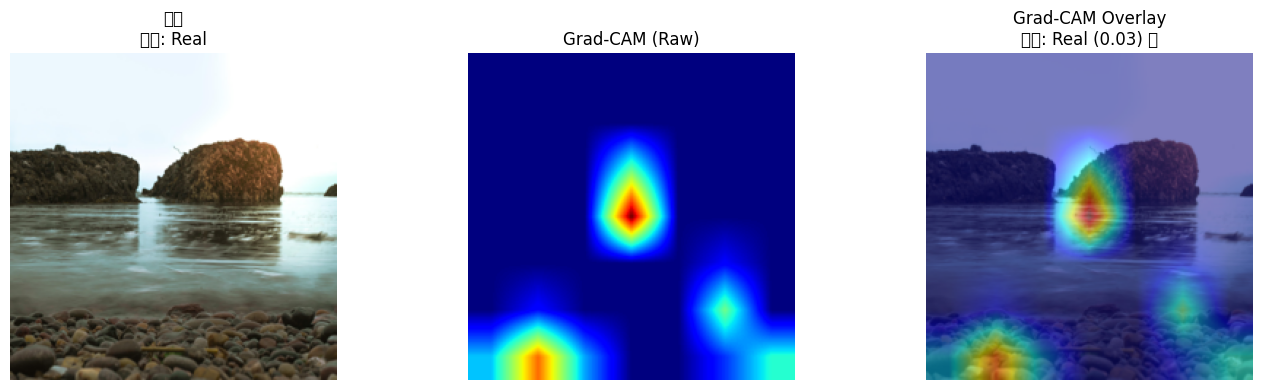

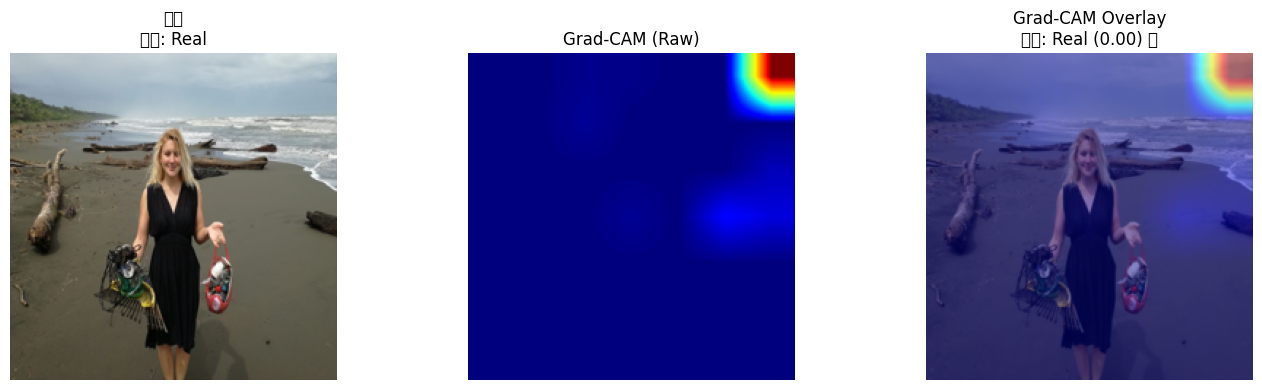

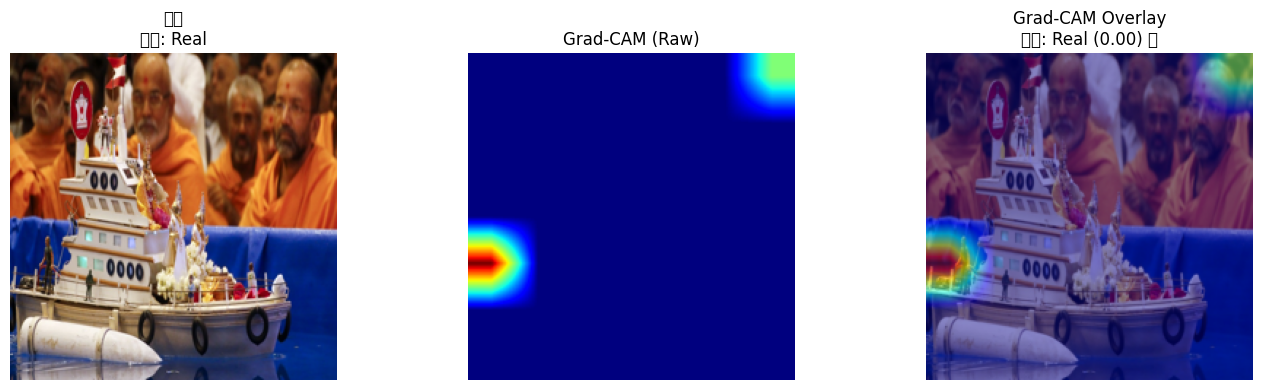

AI Generated 이미지 Grad-CAM


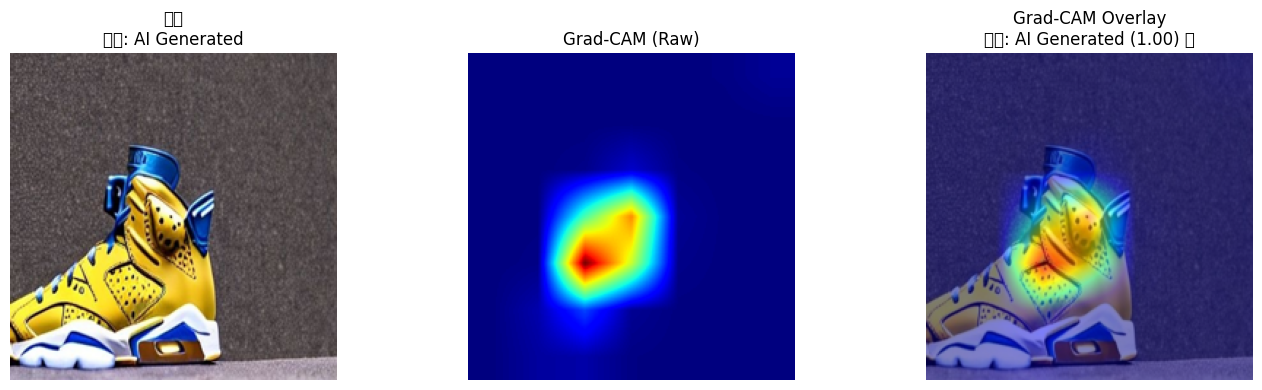

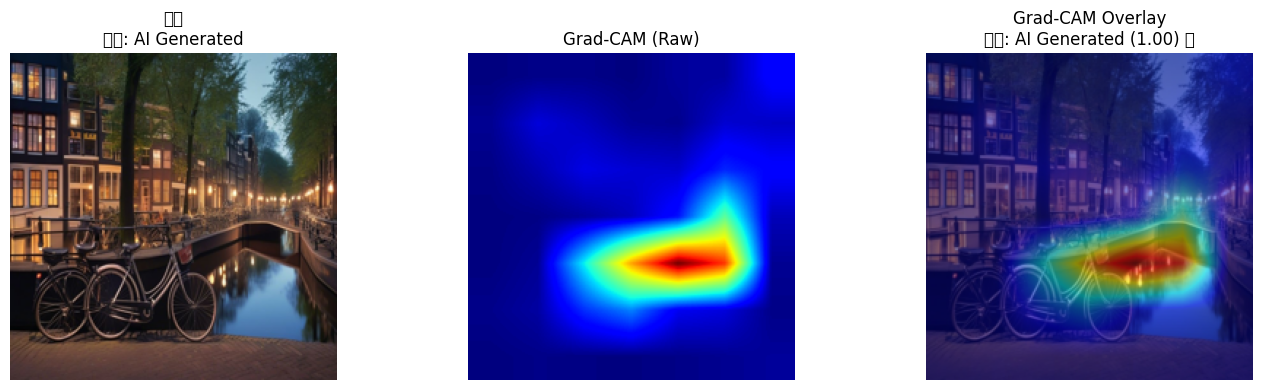

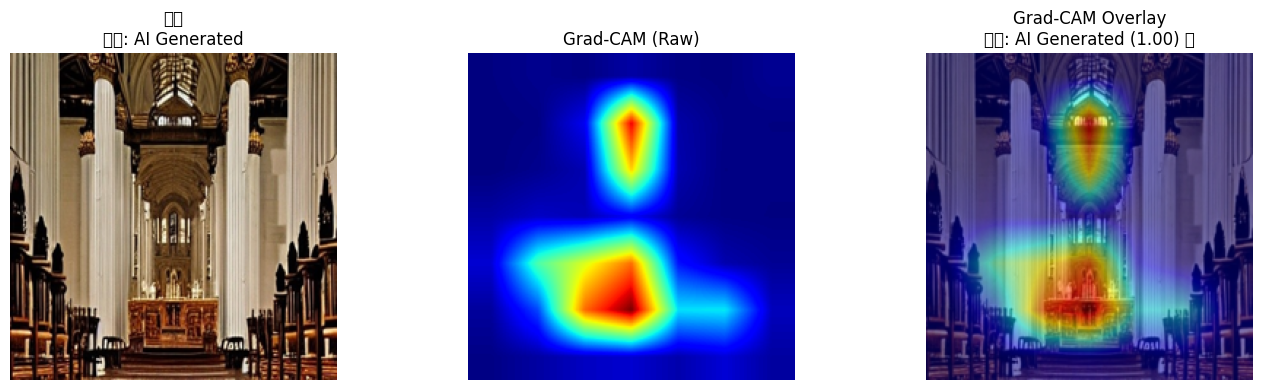

In [ ]:
# ============================================================
# Real / AI 이미지 각 3장 Grad-CAM 시각화
# ============================================================
import os
import pandas as pd

shard_path = "../data/train/shard_0"
labels_df  = pd.read_csv(os.path.join(shard_path, "labels.csv"), index_col=0)

print("=" * 50 + "\nReal 이미지 Grad-CAM\n" + "=" * 50)
for _, row in labels_df[labels_df["label"] == 0].head(3).iterrows():
    visualize_gradcam(os.path.join(shard_path, "images", row["image_name"]), true_label=0)

print("=" * 50 + "\nAI Generated 이미지 Grad-CAM\n" + "=" * 50)
for _, row in labels_df[labels_df["label"] == 1].head(3).iterrows():
    visualize_gradcam(os.path.join(shard_path, "images", row["image_name"]), true_label=1)

In [ ]:
# ============================================================
# 오분류 케이스 분석 (test set 기준)
# ============================================================
wrong_cases = []

model.eval()
for imgs, labels in test_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = (probs > 0.5).long()

    for i in range(len(labels)):
        if preds[i] != labels[i]:
            wrong_cases.append({
                "img_tensor": imgs[i].cpu(),
                "true": labels[i].item(),
                "pred": preds[i].item(),
                "prob": probs[i].item()
            })

print(f"오분류 케이스: {len(wrong_cases)}개 / {len(test_ds)}개")

for case in wrong_cases[:3]:
    img_tensor = case["img_tensor"].unsqueeze(0).to(device)

    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(1)])[0]

    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1).astype(np.float32)
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    true_str = "Real" if case["true"] == 0 else "AI Generated"
    pred_str = "Real" if case["pred"] == 0 else "AI Generated"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"정답: {true_str} → 예측: {pred_str} (AI확률: {case['prob']:.3f}) ❌")
    axes[0].imshow(img_np); axes[0].set_title("원본"); axes[0].axis("off")
    axes[1].imshow(cam_image); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    plt.tight_layout(); plt.show()

오분류 케이스: 0개 / 200개 샘플
